## Functions

In [1]:
import re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import scipy

def parse_filepath_attributes(file_path):
    # Convert string to a Path object to easily isolate folders
    path_parts = Path(file_path).parts
    
    dendrite_type = None
    slide_element = None
    slide_id = None
    
    # 1. Extract dendrite type (basal vs tuft)
    # Checking against the raw string so it catches it anywhere in the path
    if "basal" in file_path:
        dendrite_type = "basal"
    elif "tuft" in file_path:
        dendrite_type = "tuft"
        
    # 2. Extract Slide element and ID
    if "Slide" in file_path:
        # Loop through the isolated folders to find the one containing "Slide"
        for part in path_parts:
            if "Slide" in part:
                slide_element = part  # Captures the full folder name: "Slide8_well2"
                
                # Use regex to extract just the number immediately following "Slide"
                match = re.search(r'Slide(\d+)', part)
                if match:
                    slide_id = int(match.group(1))  # Captures the ID: 8
                break # Stop searching once we find the Slide folder

    return {
        "dendrite_type": dendrite_type,
        "slide_element": slide_element,
        "slide_id": slide_id
    }

def view_stack_jupyter(volume, level=176, window=67, title="Z-Stack Viewer"):


    """
    Creates a Jupyter-native interactive slider to scroll through a 3D Z-stack.
    Applies specified Window and Level for contrast.
    
    Parameters:
    - volume: 3D numpy array (Z, Y, X).
    - level: Window center for contrast.
    - window: Window width for contrast.
    - title: Optional string to display above the plot.
    """
    if volume is None or not isinstance(volume, np.ndarray):
        print("Please provide a valid 3D numpy array.")
        return

    z_dim = volume.shape[0]
    
    # Calculate contrast limits based on Window and Level
    vmin = level - (window / 2.0)
    vmax = level + (window / 2.0)

    # The plotting function that ipywidgets will call on every slider move
    def plot_slice(z_index):
        plt.figure(figsize=(10, 8))
        plt.imshow(volume[z_index], cmap='gray', vmin=vmin, vmax=vmax)
        plt.title(f"{title} | Z-Slice: {z_index} / {z_dim - 1} | L:{level} W:{window}")
        plt.axis('off')
        plt.show()

    # Generate the interactive slider UI
    slider = widgets.IntSlider(
        min=0, 
        max=z_dim - 1, 
        step=1, 
        value=0, 
        description='Z-Slice:',
        continuous_update=False  # Prevents notebook lag while dragging
    )
    
    # Bind the slider to the plotting function
    widgets.interact(plot_slice, z_index=slider)

def plot_intensity_histogram(volume, range1=(20, 50), range2=(220, 250), 
                             bins=100, method='percentile', percentile_val=95):
    """
    Calculates a projection (mean or percentile) for two Z-ranges and plots their histograms.
    
    Parameters:
    - volume: 3D numpy array (Z, Y, X).
    - range1: Tuple of (start_z, end_z) for the first block.
    - range2: Tuple of (start_z, end_z) for the second block.
    - bins: Number of histogram bins.
    - method: 'mean' or 'percentile'.
    - percentile_val: The percentile to calculate (0-100) if method='percentile'.
    """
    if volume is None or not isinstance(volume, np.ndarray):
        print("Please provide a valid 3D numpy array.")
        return

    # 1. Slice the 3D volume
    block1 = volume[range1[0] : range1[1] + 1]
    block2 = volume[range2[0] : range2[1] + 1]
    
    # 2. Apply the chosen projection method along the Z-axis (axis=0)
    if method == 'mean':
        proj1 = np.mean(block1, axis=0)
        proj2 = np.mean(block2, axis=0)
        title_prefix = "Mean"
    elif method == 'percentile':
        proj1 = np.percentile(block1, percentile_val, axis=0)
        proj2 = np.percentile(block2, percentile_val, axis=0)
        title_prefix = f"{percentile_val}th Percentile"
    else:
        print("Error: method must be either 'mean' or 'percentile'.")
        return
        
    # 3. Flatten the 2D images into 1D arrays for the histogram
    pixels1 = proj1.flatten()
    pixels2 = proj2.flatten()
    
    # 4. Plot the histograms
    plt.figure(figsize=(10, 6))
    
    plt.hist(pixels1, bins=bins, alpha=0.6, color='blue', label=f'Z-slices {range1[0]}-{range1[1]}')
    plt.hist(pixels2, bins=bins, alpha=0.6, color='orange', label=f'Z-slices {range2[0]}-{range2[1]}')
    
    plt.title(f'Histogram of {title_prefix} Pixel Intensities')
    plt.xlabel(f'{title_prefix} Pixel Intensity')
    plt.ylabel('Frequency (Pixel Count)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    
    # Optional: Uncomment if the background peak hides your signal distribution
    # plt.yscale('log') 
    
    plt.show()

def plot_z_signal_profile(volume, percentile_val=90):
    """
    Plots the sum of all pixels at or above a given percentile for every Z-slice.
    This creates a signal intensity profile across the depth of the Z-stack.
    
    Parameters:
    - volume: 3D numpy array (Z, Y, X).
    - percentile_val: The percentile threshold (0-100).
    """
    if volume is None or not isinstance(volume, np.ndarray):
        print("Please provide a valid 3D numpy array.")
        return

    print(f"Calculating the global {percentile_val}th percentile threshold...")
    # 1. Calculate the global threshold for the entire 3D volume
    threshold = np.percentile(volume, percentile_val)
    print(f"Threshold value: {threshold:.2f}")
    
    # 2. Create a mask that zeros out anything below the threshold
    # np.where(condition, true_yield, false_yield)
    masked_volume = np.where(volume >= threshold, volume, 0)
    
    # 3. Sum the remaining (bright) pixels for each individual Z-slice
    # axis=(1, 2) means it sums across the Y and X dimensions, leaving a 1D array of length Z
    z_sums = np.sum(masked_volume, axis=(1, 2))
    
    # 4. Plot the signal profile across the Z-axis
    z_slices = np.arange(len(z_sums))
    
    plt.figure(figsize=(12, 6))
    plt.plot(z_slices, z_sums, color='green', linewidth=2)
    
    # Fill the area under the curve for better visual impact
    plt.fill_between(z_slices, z_sums, color='green', alpha=0.2)
    
    plt.title(f'Signal Profile Across Z-Axis (Sum of Top {100 - percentile_val}% Pixels)')
    plt.xlabel('Z-Slice Index')
    plt.ylabel('Sum of Bright Pixels')
    plt.grid(True, alpha=0.3)
    
    plt.xlim(0, len(z_sums) - 1)
    plt.ylim(bottom=0) # Ensure the Y-axis always starts at 0
    
    plt.show()

In [2]:
import os
import glob
import re
import numpy as np
import tifffile
import roifile
import concurrent.futures

class ZStackProcessor:
    # Added roi_zip_path to the signature so it doesn't throw a NameError
    def __init__(self, base_dir_path):
        """
        Initializes the processor with paths to the required files.
        """
        # Assuming parse_filepath_attributes is defined elsewhere in your code
        properties = parse_filepath_attributes(base_dir_path)

        # Grabbing the first file for projection (adjust if your projection has a specific name)
        self.z_proj_path = glob.glob(f'{base_dir_path}/experiment/*/*.tif')[0]
        
        # This creates a list of all matching file paths
        self.z_stack_files = glob.glob(f'{base_dir_path}/experiment_z_stack/*/*.tif')
        self.roi_zip_path = glob.glob(f'{base_dir_path}/*.zip')[0]
        self.outpath = f'{base_dir_path}/outputdir'
        
        self.z_stack = None
        self.z_proj = None
        self.rois = None

        self.dendrite_type = properties['dendrite_type']
        self.slide = properties['slide_element']
        
        # Fixed duplicate xpixdim
        self.xpixdim = 0.108
        self.ypixdim = 0.108 
        self.zpixdim = 0.3
    
    def _get_z_index(self, filepath):
        """
        Helper method to extract the integer after '_z' in the filename.
        e.g., 'image_z2.tif' -> 2, 'image_z100.tif' -> 100
        """
        match = re.search(r'_z(\d+)', filepath)
        if match:
            return int(match.group(1))
        # Fallback if no '_z' is found, puts it at the start
        return -1 

    def _read_single_slice(self, index, filepath):
        """
        Worker function for the thread pool to read an image 
        and place it directly into the pre-allocated array.
        """
        self.z_stack[index, :, :] = tifffile.imread(filepath)

    def load_files(self):
        """
        Sorts files, pre-allocates memory, and loads Z-slices concurrently.
        """
        if not self.z_stack_files:
            raise ValueError("No Z-stack files were found during initialization.")

        print(f"Sorting and loading {len(self.z_stack_files)} Z-Stack images...")
        
        # 1. Sort the list using our custom regex function
        self.z_stack_files.sort(key=self._get_z_index)
        
        # 2. Read the first slice to determine shape and data type
        first_slice = tifffile.imread(self.z_stack_files[0])
        z_dim = len(self.z_stack_files)
        y_dim, x_dim = first_slice.shape
        
        # 3. Pre-allocate the full 3D array (saves memory and stacking time)
        self.z_stack = np.empty((z_dim, y_dim, x_dim), dtype=first_slice.dtype)
        
        # Insert the first slice since we already read it
        self.z_stack[0, :, :] = first_slice
        
        # 4. Multithread the loading of the remaining files
        print("Reading files concurrently from disk...")
        with concurrent.futures.ThreadPoolExecutor() as executor:
            # We skip index 0 since we already loaded it
            futures = [
                executor.submit(self._read_single_slice, i, self.z_stack_files[i]) 
                for i in range(1, z_dim)
            ]
            # Wait for all threads to finish
            concurrent.futures.wait(futures)
            
        print(f"Constructed Z-Stack volume with shape: {self.z_stack.shape}")
        
        print("Loading Z-Projection...")
        self.z_proj = tifffile.imread(self.z_proj_path)
        
        print("Loading ROIs...")
        self.rois = roifile.roiread(self.roi_zip_path)

    def plot_rois_on_projection(self, figsize=(12, 12), line_color='red', 
                                vmin=None, vmax=None, level=176, window=67):
        """
        Plots the Z-projection with ROIs.
        Accepts EITHER vmin/vmax directly OR level/window.
        """
        import matplotlib.pyplot as plt

        if self.z_proj is None or self.rois is None:
            print("Data not loaded. Loading files first...")
            self.load_files()

        # If Level and Window are provided, convert them to vmin/vmax
        if level is not None and window is not None:
            vmin = level - (window / 2.0)
            vmax = level + (window / 2.0)
            
        # Fallback: if nothing is provided, use the image's actual min/max
        if vmin is None or vmax is None:
            vmin = np.min(self.z_proj)
            vmax = np.max(self.z_proj)

        plt.figure(figsize=figsize)
        
        # Apply the contrast limits
        plt.imshow(self.z_proj, cmap='gray', vmin=vmin, vmax=vmax)

        for i, roi in enumerate(self.rois):
            coords = roi.coordinates()
            if coords is not None and len(coords) > 0:
                x = np.append(coords[:, 0], coords[0, 0])
                y = np.append(coords[:, 1], coords[0, 1])
                
                plt.plot(x, y, color=line_color, linewidth=1.5)
                plt.text(roi.left, roi.top - 5, f"ROI {i+1}", 
                         color='yellow', fontsize=10, weight='bold')

        title_str = f"Slide: {self.slide} | Type: {self.dendrite_type}"
        if level and window:
            title_str += f" | L:{level} W:{window}"
        else:
            title_str += f" | Min:{vmin} Max:{vmax}"
            
        plt.title(title_str)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
    def extract_subvolumes(self, percentile_val=99, min_prominence_ratio=0.05, peak_rel_height=0.85, z_buffer=2, roi_index=None):
        """
        Crops the Z-stack in XY using the ROIs, then crops in Z based on the 
        prominence of the signal peak (sum of top percentile pixels).
        """

        if self.z_stack is None:
            self.load_files()
        output_dir = self.outpath

        os.makedirs(output_dir, exist_ok=True)
        max_z, max_y, max_x = self.z_stack.shape

        for i, roi in enumerate(self.rois):
            # If a specific roi_index is provided, skip all others
            if roi_index is not None and i != roi_index:
                continue

            # 1. Get XY bounding box from the ROI
            y1 = max(0, int(roi.top))
            y2 = min(max_y, int(roi.bottom))
            x1 = max(0, int(roi.left))
            x2 = min(max_x, int(roi.right))

            # 2. Crop the full Z-stack in X and Y
            xy_cropped_stack = self.z_stack[:, y1:y2, x1:x2]

            # 3. Z-Cropping Logic based on Peak Prominence
            # Force percentile_val to a float to prevent NumPy strict casting errors
            pixel_threshold = np.percentile(xy_cropped_stack, float(percentile_val))
            
            # Mask out the background (set anything below the threshold to 0)
            masked_volume = np.where(xy_cropped_stack >= pixel_threshold, xy_cropped_stack, 0)
            
            # Sum the surviving bright pixels for each Z-slice
            z_sums = np.sum(masked_volume, axis=(1, 2))
            
            # Find all peaks in the signal.
            min_prominence = np.max(z_sums) * min_prominence_ratio
            peaks, properties = scipy.signal.find_peaks(z_sums, prominence=min_prominence)

            if len(peaks) == 0:
                print(f"ROI {i+1}: No distinct signal peaks found. Skipping.")
                continue

            # Identify the single most prominent peak
            best_peak_idx = np.argmax(properties["prominences"])
            best_peak = peaks[best_peak_idx]

            # Calculate the width of this specific peak near its base
            widths, width_heights, left_ips, right_ips = scipy.signal.peak_widths(
                z_sums, [best_peak], rel_height=peak_rel_height
            )

            # Convert the interpolated left/right edges to integer Z-indices
            detected_start = int(left_ips[0])
            detected_end = int(right_ips[0])

            # 4. Apply the Z-buffer and clamp to valid Z-stack boundaries
            start_z = max(0, detected_start - z_buffer)
            end_z = min(max_z, detected_end + z_buffer + 1) 

            # 5. Final 3D Crop
            final_crop = xy_cropped_stack[start_z:end_z, :, :]

            # 6. Save the resulting sub-volume
            out_filename = f"{self.slide}_{self.dendrite_type}_ROI_{i+1}_Z{start_z}-{end_z-1}.tif"
            out_path = os.path.join(output_dir, out_filename)
            
            # Save using tifffile
            tifffile.imwrite(
                out_path, 
                final_crop, 
                imagej=True,
                resolution=(1./self.xpixdim, 1./self.ypixdim),
                metadata={'spacing': self.zpixdim, 'unit': 'um'}
            )
            
            print(f"Saved {out_filename} (Shape: {final_crop.shape})")


## Example processing

In [3]:
z_proj_path = r'Z:\2026 - E19 Project collab spine and dendrites\Spine\60x_dataset\Slide8_well2\basal\Rumbaugh_e19_60X_targetoverview_20260618_094722'
test = ZStackProcessor(z_proj_path)

In [4]:
test.load_files()

Sorting and loading 562 Z-Stack images...
Reading files concurrently from disk...
Constructed Z-Stack volume with shape: (562, 2304, 2304)
Loading Z-Projection...
Loading ROIs...


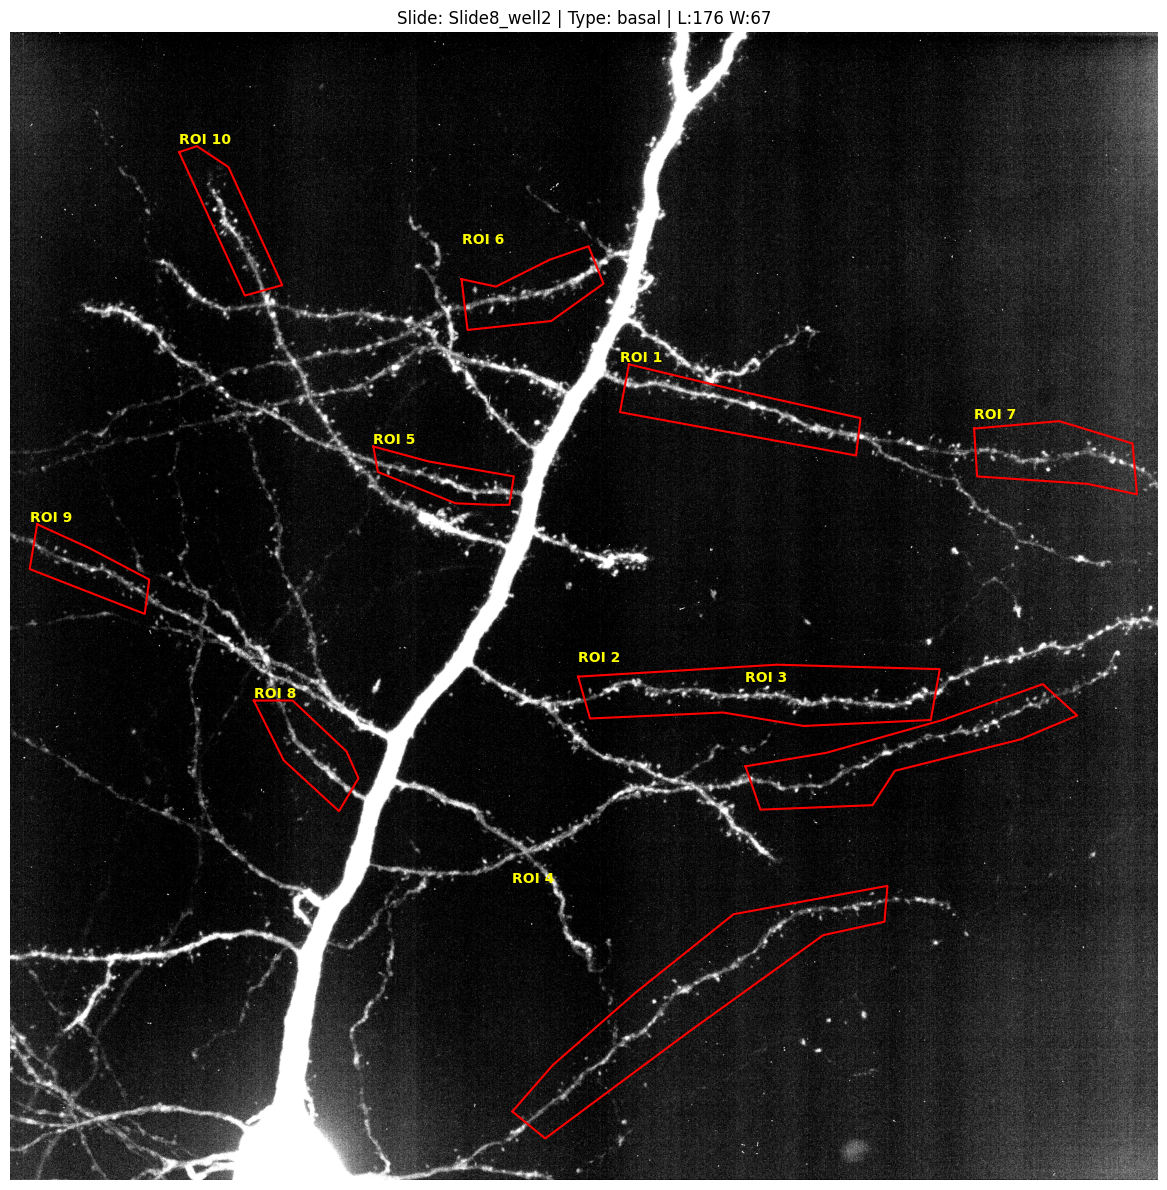

In [5]:
test.plot_rois_on_projection()

In [6]:
test.extract_subvolumes(z_buffer=10, roi_index=None)

Saved Slide8_well2_basal_ROI_1_Z73-147.tif (Shape: (75, 183, 483))
Saved Slide8_well2_basal_ROI_2_Z63-101.tif (Shape: (39, 123, 726))
Saved Slide8_well2_basal_ROI_3_Z83-137.tif (Shape: (55, 252, 666))
Saved Slide8_well2_basal_ROI_4_Z111-158.tif (Shape: (48, 507, 753))
Saved Slide8_well2_basal_ROI_5_Z84-145.tif (Shape: (62, 117, 282))
Saved Slide8_well2_basal_ROI_6_Z42-88.tif (Shape: (47, 168, 285))
Saved Slide8_well2_basal_ROI_7_Z56-106.tif (Shape: (51, 147, 327))
Saved Slide8_well2_basal_ROI_8_Z155-241.tif (Shape: (87, 222, 210))
Saved Slide8_well2_basal_ROI_9_Z82-121.tif (Shape: (40, 180, 240))
ROI 10: No distinct signal peaks found. Skipping.


## Data exploration for defining z-cropping

In [ ]:
roi = test.rois[0]
max_z, max_y, max_x = test.z_stack.shape


y1 = max(0, int(roi.top))
y2 = min(max_y, int(roi.bottom))
x1 = max(0, int(roi.left))
x2 = min(max_x, int(roi.right))

# 2. Crop the full Z-stack in X and Y
xy_cropped_stack = test.z_stack[:, y1:y2, x1:x2]

In [ ]:
view_stack_jupyter(xy_cropped_stack, level=176, window=150)

In [ ]:
plot_intensity_histogram(xy_cropped_stack, bins=100, percentile_val=90)

In [ ]:
plot_z_signal_profile(xy_cropped_stack, 99)